In [ ]:
import sys; print(sys.executable)

In [16]:
# Basic Import
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt 
import seaborn as sns
# Modelling
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
from sklearn.neighbors import KNeighborsRegressor
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor,AdaBoostRegressor
from sklearn.svm import SVR
from sklearn.linear_model import LinearRegression, Ridge,Lasso
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import RandomizedSearchCV
from catboost import CatBoostRegressor
from xgboost import XGBRegressor
import warnings

In [2]:
df = pd.read_csv('data/stud.csv')
df.head()

,gender,race_ethnicity,parental_level_of_education,lunch,test_preparation_course,math_score,reading_score,writing_score
0,female,group B,bachelor's degree,standard,none,72,72,74
1,female,group C,some college,standard,completed,69,90,88
2,female,group B,master's degree,standard,none,90,95,93
3,male,group A,associate's degree,free/reduced,none,47,57,44
4,male,group C,some college,standard,none,76,78,75


In [3]:
#Preparing X and Y variable
target_column = 'math_score'
X = df.drop(target_column, axis=1)
y = df[target_column]

In [9]:
# Create column transformer
num_features = X.select_dtypes(exclude='object').columns
cat_features = X.select_dtypes(include='object').columns

from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder, StandardScaler

numeric_transformer = StandardScaler()
categorical_transformer = OneHotEncoder()

preprocessor = ColumnTransformer(
    transformers=[
        ('StandardScaler', numeric_transformer, num_features),
        ('OneHotEncoder', categorical_transformer, cat_features)
    ]
)


In [11]:
X = preprocessor.fit_transform(X)

ValueError: Specifying the columns using strings is only supported for pandas DataFrames

In [12]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((800, 19), (200, 19), (800,), (200,))

In [22]:
#Creating a function to train and evaluate the model
def train_and_evaluate_model(model, X_train, X_test, y_train, y_test):
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)
    return mae, mse, r2

In [25]:
models = {
    'KNeighborsRegressor': KNeighborsRegressor(),
    'DecisionTreeRegressor': DecisionTreeRegressor(),
    'RandomForestRegressor': RandomForestRegressor(),
    'AdaBoostRegressor': AdaBoostRegressor(),
    'SVR': SVR(),
    'LinearRegression': LinearRegression(),
    'Ridge': Ridge(),
    'Lasso': Lasso(),
    'CatBoostRegressor': CatBoostRegressor(),
    'XGBRegressor': XGBRegressor()
}

model_results = {}
for model_name, model in models.items():
    mae, mse, r2 = train_and_evaluate_model(model, X_train, X_test, y_train, y_test)
    model_results[model_name] = {
        'MAE': mae,
        'MSE': mse,
        'R2': r2
    }


print("Model Evaluation Results:")
for model_name, results in model_results.items():
    print(f"\n{model_name}:")
    for metric, value in results.items():
        print(f"  {metric}: {value}")

Learning rate set to 0.039525
0:	learn: 14.5987177	total: 2.22ms	remaining: 2.22s
1:	learn: 14.2251886	total: 4.54ms	remaining: 2.26s
2:	learn: 13.8866124	total: 6.86ms	remaining: 2.28s
3:	learn: 13.5235688	total: 8.72ms	remaining: 2.17s
4:	learn: 13.1887021	total: 10.6ms	remaining: 2.12s
5:	learn: 12.9124226	total: 13.1ms	remaining: 2.16s
6:	learn: 12.6000335	total: 15.3ms	remaining: 2.17s
7:	learn: 12.3299057	total: 17.5ms	remaining: 2.17s
8:	learn: 12.0660619	total: 19.3ms	remaining: 2.13s
9:	learn: 11.7730981	total: 21.3ms	remaining: 2.1s
10:	learn: 11.4922764	total: 23.3ms	remaining: 2.1s
11:	learn: 11.2626483	total: 25.6ms	remaining: 2.1s
12:	learn: 11.0426039	total: 28ms	remaining: 2.13s
13:	learn: 10.7991693	total: 31.3ms	remaining: 2.2s
14:	learn: 10.5541002	total: 34.1ms	remaining: 2.24s
15:	learn: 10.3191811	total: 36.5ms	remaining: 2.24s
16:	learn: 10.1000444	total: 38.8ms	remaining: 2.24s
17:	learn: 9.8945567	total: 41ms	remaining: 2.24s
18:	learn: 9.6901741	total: 44.1ms	

In [26]:
pd.DataFrame(model_results).T.sort_values(by='R2', ascending=False)

,MAE,MSE,R2
Ridge,4.211101,29.056272,0.880593
LinearRegression,4.214763,29.095170,0.880433
CatBoostRegressor,4.612532,36.103658,0.851632
AdaBoostRegressor,4.724297,36.415116,0.850352
RandomForestRegressor,4.636342,36.703188,0.849168
Lasso,5.157879,42.506332,0.825320
XGBRegressor,5.103629,43.503920,0.821220
KNeighborsRegressor,5.619000,52.617000,0.783770
SVR,5.401539,66.042005,0.728600
DecisionTreeRegressor,6.560000,66.520000,0.726636


In [28]:
#Linear Regression
linear_model = LinearRegression()
linear_model.fit(X_train, y_train)
y_pred_linear = linear_model.predict(X_test)
score_linear = r2_score(y_test, y_pred_linear)
print(f"Linear Regression R2 Score: {score_linear:.2f}")

Linear Regression R2 Score: 0.88


Text(0.5, 0, 'Actual Math Scores')

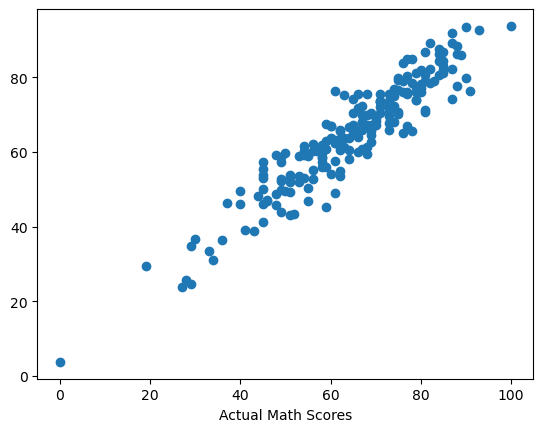

In [29]:
#Plotting the results
plt.scatter(y_test, y_pred_linear)
plt.xlabel("Actual Math Scores")

In [33]:
 #Difference between actual and predicted values
residuals = y_test - y_pred_linear
pd.DataFrame({'Actual values': y_test, 'Predicted values': y_pred_linear, 'Residuals': residuals}).head()


,Actual values,Predicted values,Residuals
521,91,76.387970,14.612030
737,53,58.885970,-5.885970
740,80,76.990265,3.009735
660,74,76.851804,-2.851804
411,84,87.627378,-3.627378
